# Chapter 10 Teaching Notebook: Regional Ocean Wave Height Prediction with U-Net

This notebook demonstrates a compact workflow for regional significant wave height (SWH) prediction. The model uses historical wind and wave fields as gridded inputs and predicts future SWH maps over the target region. The code is organized as a teaching example, so the main steps are kept explicit: data loading, normalization, sample construction, U-Net model definition, training, evaluation, and visualization.

## 1. Training a U-Net wave forecaster

This section reads two years of gridded wind-wave data, constructs sliding-window samples, and trains a U-Net model. The input sequence contains past hourly fields of 10 m wind components and SWH, while the target is the future SWH sequence. A sea mask is used so that loss values and evaluation metrics are calculated only over valid ocean grid cells.

In [1]:
# ============================================================
# Chapter 10: Regional ocean wave modeling using U-Net
# Two-year demo experiment
# Train: 2023 Jan - 2024 Aug
# Val  : 2024 Sep - 2024 Oct
# Input : past [u10, v10, swh]
# Output: future swh
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import xarray as xr

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


# =========================
# 1. CONFIG
# =========================
# All key experiment settings are collected here so that students can
# quickly modify the observation length, forecast horizon, and model size.
CONFIG = {
    "data_dir": ".",
    "data_files": [
        "combined_wind_wave_2023.nc",
        "combined_wind_wave_2024.nc"
    ],

    "train_start": "2023-01-01",
    "train_end":   "2024-08-31",
    "val_start":   "2024-09-01",
    "val_end":     "2024-10-31",

    "seq_len": 72,        # past 72 hours
    "pred_len": 24,       # future 24 hours
    "stride": 6,          # sample every 6 hours

    "batch_size": 2,
    "hidden_dim": 16,
    "kernel_size": 3,

    "lr": 5e-4,
    "epochs": 30,
    "num_workers": 0,

    "save_dir": "wave_unet_2023_2024_demo",
    "best_model_name": "best_unet_swh.pth",
    "log_csv_name": "training_log.csv",

    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)

BEST_MODEL_PATH = os.path.join(CONFIG["save_dir"], CONFIG["best_model_name"])
LOG_CSV_PATH = os.path.join(CONFIG["save_dir"], CONFIG["log_csv_name"])

if os.path.exists(LOG_CSV_PATH):
    os.remove(LOG_CSV_PATH)

print("Using device:", CONFIG["device"])


# =========================
# 2. Data loading
# =========================
def get_time_dim(ds):
    for name in ["valid_time", "time"]:
        if name in ds.dims:
            return name
    raise ValueError("No time dimension found. Expected 'valid_time' or 'time'.")


def extract_xy(ds, time_dim):
    ds = ds.sortby(time_dim)

    u10 = ds["u10"].transpose(time_dim, ...).values.astype(np.float32)
    v10 = ds["v10"].transpose(time_dim, ...).values.astype(np.float32)
    swh = ds["swh"].transpose(time_dim, ...).values.astype(np.float32)

    X = np.stack([u10, v10, swh], axis=1)  # (T, C, H, W)
    y = swh                                # (T, H, W)

    return X, y


datasets = []

for file_name in CONFIG["data_files"]:
    file_path = os.path.join(CONFIG["data_dir"], file_name)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    datasets.append(xr.open_dataset(file_path))

time_dim = get_time_dim(datasets[0])

ds = xr.concat(
    datasets,
    dim=time_dim,
    coords="minimal",
    compat="override",
    combine_attrs="override"
).sortby(time_dim)

train_ds = ds.sel({time_dim: slice(CONFIG["train_start"], CONFIG["train_end"])})
val_ds   = ds.sel({time_dim: slice(CONFIG["val_start"], CONFIG["val_end"])})

X_train_raw, y_train_raw = extract_xy(train_ds, time_dim)
X_val_raw, y_val_raw = extract_xy(val_ds, time_dim)

for d in datasets:
    d.close()

# The sea mask excludes land or invalid grid cells from the loss and metrics.
sea_mask = np.isfinite(y_train_raw).any(axis=0).astype(np.float32)

print("Train raw:", X_train_raw.shape, y_train_raw.shape)
print("Val raw:  ", X_val_raw.shape, y_val_raw.shape)
print("Sea grid cells:", int(sea_mask.sum()))


# =========================
# 3. Normalization
# =========================
def compute_stats(X, y, mask):
    x_mean, x_std = [], []

    for c in range(X.shape[1]):
        values = X[:, c, :, :][:, mask > 0]
        x_mean.append(np.nanmean(values))
        x_std.append(np.nanstd(values))

    y_values = y[:, mask > 0]

    return (
        np.array(x_mean, dtype=np.float32),
        np.array(x_std, dtype=np.float32),
        np.float32(np.nanmean(y_values)),
        np.float32(np.nanstd(y_values))
    )


def normalize_X(X, x_mean, x_std):
    X = (X - x_mean[None, :, None, None]) / (x_std[None, :, None, None] + 1e-6)
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def normalize_y(y, y_mean, y_std):
    y = (y - y_mean) / (y_std + 1e-6)
    return np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


x_mean, x_std, y_mean, y_std = compute_stats(X_train_raw, y_train_raw, sea_mask)

X_train = normalize_X(X_train_raw, x_mean, x_std)
y_train = normalize_y(y_train_raw, y_mean, y_std)

X_val = normalize_X(X_val_raw, x_mean, x_std)
y_val = normalize_y(y_val_raw, y_mean, y_std)

del X_train_raw, y_train_raw, X_val_raw, y_val_raw

print("Normalization finished.")
print("x_mean:", x_mean)
print("x_std :", x_std)
print("y_mean:", y_mean)
print("y_std :", y_std)


# =========================
# 4. Dataset
# =========================
# Each sample contains a past sequence of wind-wave fields and the following
# future SWH maps. This converts gridded time series into supervised samples.
class WaveDataset(Dataset):
    def __init__(self, X, y, mask, seq_len, pred_len, stride):
        self.X = X
        self.y = y
        self.mask = mask.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.stride = stride

        self.max_start = len(X) - seq_len - pred_len
        self.num_samples = self.max_start // stride + 1

    def __len__(self):
        return max(0, self.num_samples)

    def __getitem__(self, idx):
        start = idx * self.stride
        end_x = start + self.seq_len
        end_y = end_x + self.pred_len

        x_seq = self.X[start:end_x]      # (T_in, C, H, W)
        y_seq = self.y[end_x:end_y]      # (T_out, H, W)

        return (
            torch.from_numpy(x_seq),
            torch.from_numpy(y_seq),
            torch.from_numpy(self.mask)
        )


train_dataset = WaveDataset(
    X_train, y_train, sea_mask,
    CONFIG["seq_len"], CONFIG["pred_len"], CONFIG["stride"]
)

val_dataset = WaveDataset(
    X_val, y_val, sea_mask,
    CONFIG["seq_len"], CONFIG["pred_len"], CONFIG["stride"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True if CONFIG["device"] == "cuda" else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True if CONFIG["device"] == "cuda" else False
)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))


# =========================
# 5. U-Net model
# =========================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNetForecaster(nn.Module):
    def __init__(self, input_dim, seq_len, base_channels, pred_len):
        super().__init__()

        in_channels = input_dim * seq_len

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, pred_len, kernel_size=1)

    def match_size(self, x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)
        return x

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        # U-Net uses 2D convolution. The temporal and variable dimensions
        # are stacked as channels: (B, T*C, H, W).
        x = x.reshape(B, T * C, H, W)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.match_size(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.match_size(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.match_size(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.match_size(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = self.out_conv(d1)  # (B, pred_len, H, W)

        return out


model = UNetForecaster(
    input_dim=3,
    seq_len=CONFIG["seq_len"],
    base_channels=CONFIG["hidden_dim"],
    pred_len=CONFIG["pred_len"]
).to(CONFIG["device"])

optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])


# =========================
# 6. Loss and metrics
# =========================
def masked_mse_loss(pred, target, mask):
    mask = mask.unsqueeze(1)
    loss = ((pred - target) ** 2) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + 1e-6)


def inverse_y(y_norm):
    return y_norm * (y_std + 1e-6) + y_mean


class MetricMeter:
    def __init__(self):
        self.sse = 0.0
        self.sae = 0.0
        self.sape = 0.0
        self.bias_sum = 0.0
        self.y_sum = 0.0
        self.y2_sum = 0.0
        self.n = 0.0

    def update(self, pred, target, mask):
        with torch.no_grad():
            valid = mask.unsqueeze(1).expand_as(target) > 0.5

            pred_v = pred[valid]
            target_v = target[valid]
            err = pred_v - target_v

            self.sse += torch.sum(err ** 2).item()
            self.sae += torch.sum(torch.abs(err)).item()
            self.sape += torch.sum(
                torch.abs(err) / torch.clamp(torch.abs(target_v), min=0.05)
            ).item()
            self.bias_sum += torch.sum(err).item()
            self.y_sum += torch.sum(target_v).item()
            self.y2_sum += torch.sum(target_v ** 2).item()
            self.n += target_v.numel()

    def compute(self):
        mse = self.sse / (self.n + 1e-6)
        mae = self.sae / (self.n + 1e-6)
        rmse = math.sqrt(mse)
        mape = self.sape / (self.n + 1e-6) * 100.0
        bias = self.bias_sum / (self.n + 1e-6)

        y_bar = self.y_sum / (self.n + 1e-6)
        sst = self.y2_sum - 2 * y_bar * self.y_sum + self.n * y_bar ** 2
        r2 = 1.0 - self.sse / (sst + 1e-6)

        return mae, mse, rmse, mape, bias, r2


# =========================
# 7. Training
# =========================
best_val_mae = float("inf")

for epoch in range(1, CONFIG["epochs"] + 1):

    model.train()
    train_loss_sum = 0.0
    train_meter = MetricMeter()

    total_steps = len(train_loader) + len(val_loader)

    pbar = tqdm(
        total=total_steps,
        desc=f"Epoch {epoch:03d}/{CONFIG['epochs']}",
        dynamic_ncols=True,
        leave=False,
        mininterval=0.5,
        position=0
    )

    for batch_x, batch_y, batch_mask in train_loader:
        batch_x = batch_x.to(CONFIG["device"], non_blocking=True)
        batch_y = batch_y.to(CONFIG["device"], non_blocking=True)
        batch_mask = batch_mask.to(CONFIG["device"], non_blocking=True)

        optimizer.zero_grad()

        pred = model(batch_x)
        loss = masked_mse_loss(pred, batch_y, batch_mask)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item()

        train_meter.update(
            inverse_y(pred.detach()),
            inverse_y(batch_y.detach()),
            batch_mask
        )

        pbar.set_postfix({"stage": "train", "loss": f"{loss.item():.5f}"})
        pbar.update(1)

    train_loss = train_loss_sum / max(len(train_loader), 1)
    train_mae, train_mse, train_rmse, train_mape, train_bias, train_r2 = train_meter.compute()

    model.eval()
    val_loss_sum = 0.0
    val_meter = MetricMeter()

    with torch.no_grad():
        for batch_x, batch_y, batch_mask in val_loader:
            batch_x = batch_x.to(CONFIG["device"], non_blocking=True)
            batch_y = batch_y.to(CONFIG["device"], non_blocking=True)
            batch_mask = batch_mask.to(CONFIG["device"], non_blocking=True)

            pred = model(batch_x)
            loss = masked_mse_loss(pred, batch_y, batch_mask)

            val_loss_sum += loss.item()

            val_meter.update(
                inverse_y(pred),
                inverse_y(batch_y),
                batch_mask
            )

            pbar.set_postfix({"stage": "val", "loss": f"{loss.item():.5f}"})
            pbar.update(1)

    pbar.close()

    val_loss = val_loss_sum / max(len(val_loader), 1)
    val_mae, val_mse, val_rmse, val_mape, val_bias, val_r2 = val_meter.compute()

    row = {
        "epoch": epoch,

        "train_loss": train_loss,
        "train_mae_m": train_mae,
        "train_mse_m2": train_mse,
        "train_rmse_m": train_rmse,
        "train_mape_percent": train_mape,
        "train_bias_m": train_bias,
        "train_r2": train_r2,

        "val_loss": val_loss,
        "val_mae_m": val_mae,
        "val_mse_m2": val_mse,
        "val_rmse_m": val_rmse,
        "val_mape_percent": val_mape,
        "val_bias_m": val_bias,
        "val_r2": val_r2
    }

    pd.DataFrame([row]).to_csv(
        LOG_CSV_PATH,
        mode="a",
        header=not os.path.exists(LOG_CSV_PATH),
        index=False
    )

    if val_mae < best_val_mae:
        best_val_mae = val_mae

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_mae": best_val_mae,
            "config": CONFIG,
            "x_mean": x_mean,
            "x_std": x_std,
            "y_mean": y_mean,
            "y_std": y_std,
            "sea_mask": sea_mask
        }, BEST_MODEL_PATH)

        save_info = " | best model saved"
    else:
        save_info = ""

    print(
        f"Epoch {epoch:03d}/{CONFIG['epochs']} | "
        f"Train Loss: {train_loss:.6f} | Train MAE: {train_mae:.4f} m | "
        f"Val Loss: {val_loss:.6f} | Val MAE: {val_mae:.4f} m | "
        f"Val RMSE: {val_rmse:.4f} m | Val R2: {val_r2:.4f}"
        f"{save_info}"
    )


print("\nTraining finished.")
print("Best model saved to:", BEST_MODEL_PATH)
print("Training log saved to:", LOG_CSV_PATH)

/slurm/home/yrd/luolab/zhaoliang/miniconda3/envs/book/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Train raw: (14616, 3, 91, 71) (14616, 91, 71)
Val raw:   (1464, 3, 91, 71) (1464, 91, 71)
Sea grid cells: 3574
Normalization finished.
x_mean: [-1.3167372  -0.39234802  1.2063897 ]
x_std : [4.340903  4.5405703 0.8040446]
y_mean: 1.2063897
y_std : 0.8040446
Train samples: 2421
Val samples:   229


Epoch 001/30 | Train Loss: 0.216456 | Train MAE: 0.2321 m | Val Loss: 0.231329 | Val MAE: 0.2146 m | Val RMSE: 0.3861 m | Val R2: 0.8386 | best model saved


Epoch 002/30 | Train Loss: 0.120722 | Train MAE: 0.1711 m | Val Loss: 0.212732 | Val MAE: 0.2206 m | Val RMSE: 0.3691 m | Val R2: 0.8524


Epoch 003/30 | Train Loss: 0.104060 | Train MAE: 0.1570 m | Val Loss: 0.166963 | Val MAE: 0.1865 m | Val RMSE: 0.3263 m | Val R2: 0.8847 | best model saved


...

Epoch 026/30 | Train Loss: 0.043493 | Train MAE: 0.1069 m | Val Loss: 0.130330 | Val MAE: 0.1569 m | Val RMSE: 0.2890 m | Val R2: 0.9096


Epoch 027/30 | Train Loss: 0.042536 | Train MAE: 0.1059 m | Val Loss: 0.136496 | Val MAE: 0.1652 m | Val RMSE: 0.2951 m | Val R2: 0.9057


Epoch 028/30 | Train Loss: 0.042587 | Train MAE: 0.1062 m | Val Loss: 0.126447 | Val MAE: 0.1556 m | Val RMSE: 0.2841 m | Val R2: 0.9126 | best model saved


Epoch 029/30 | Train Loss: 0.040682 | Train MAE: 0.1039 m | Val Loss: 0.133449 | Val MAE: 0.1599 m | Val RMSE: 0.2916 m | Val R2: 0.9079


Epoch 030/30 | Train Loss: 0.039638 | Train MAE: 0.1028 m | Val Loss: 0.139712 | Val MAE: 0.1625 m | Val RMSE: 0.2993 m | Val R2: 0.9030

Training finished.
Best model saved to: wave_unet_2023_2024_demo/best_unet_swh.pth
Training log saved to: wave_unet_2023_2024_demo/training_log.csv


## 2. Visualizing one validation prediction

This section reloads the best saved U-Net checkpoint and visualizes one validation forecast against the corresponding true SWH map. The visualization is intended to show the spatial prediction pattern rather than only reporting scalar metrics.

/tmp/ipykernel_21969/4027300577.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODEL_PATH, map_location=DEVICE)


Loaded model: wave_unet_2023_2024_demo/best_unet_swh.pth
Prediction target time: 2024-09-04T00:00:00.000000000


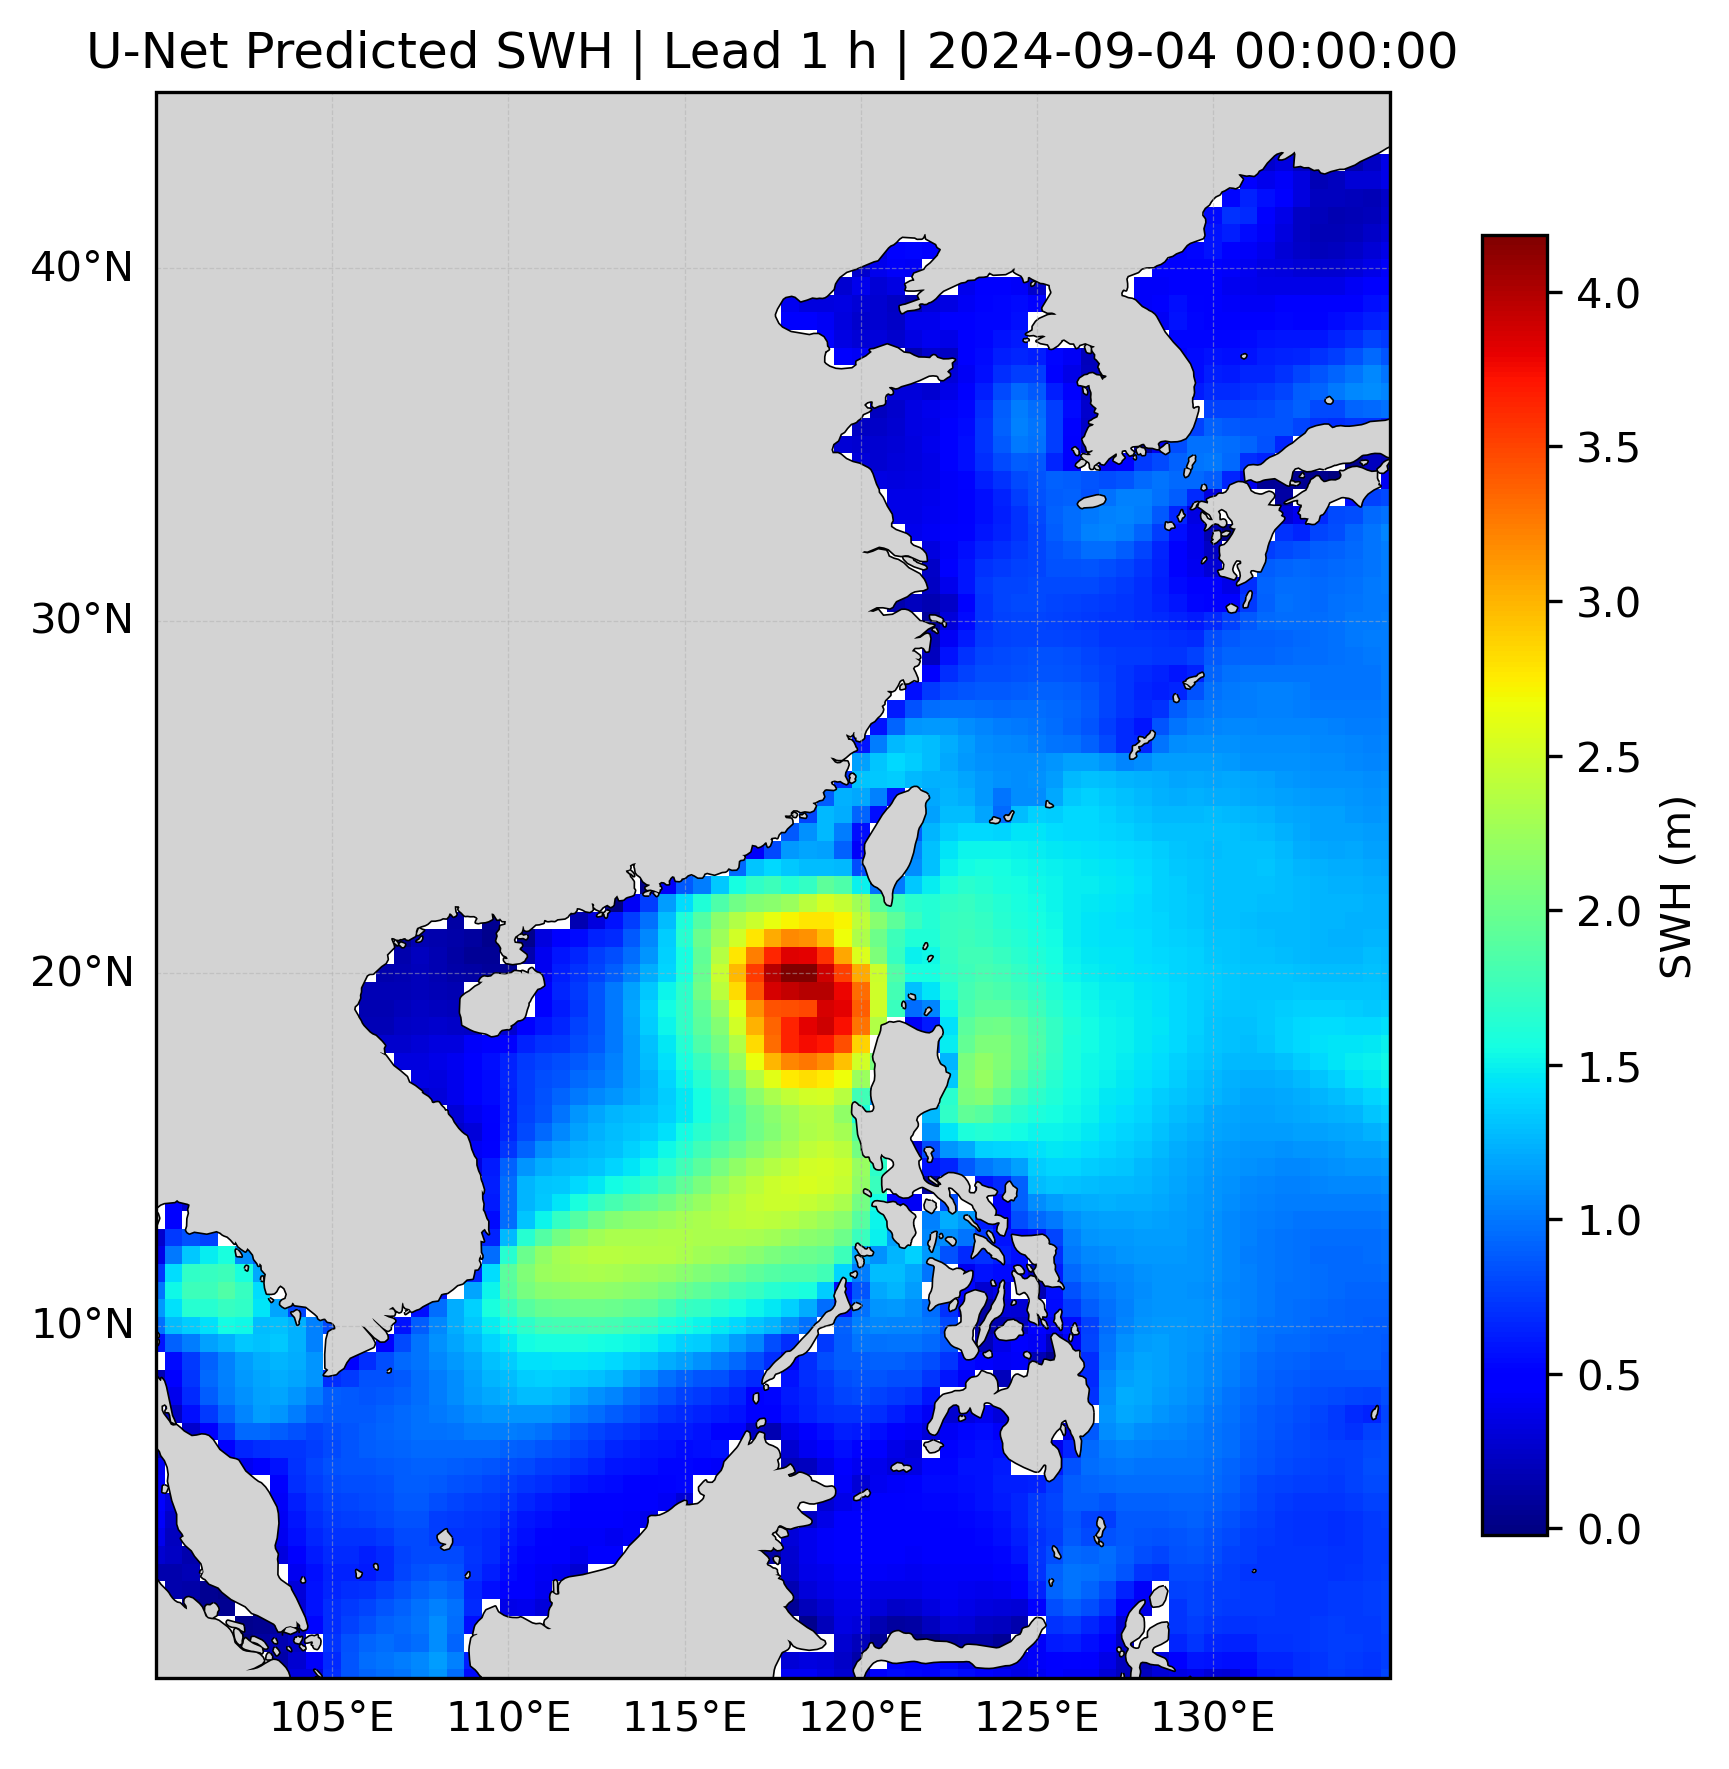

Saved: unet_predicted_swh_validation.png


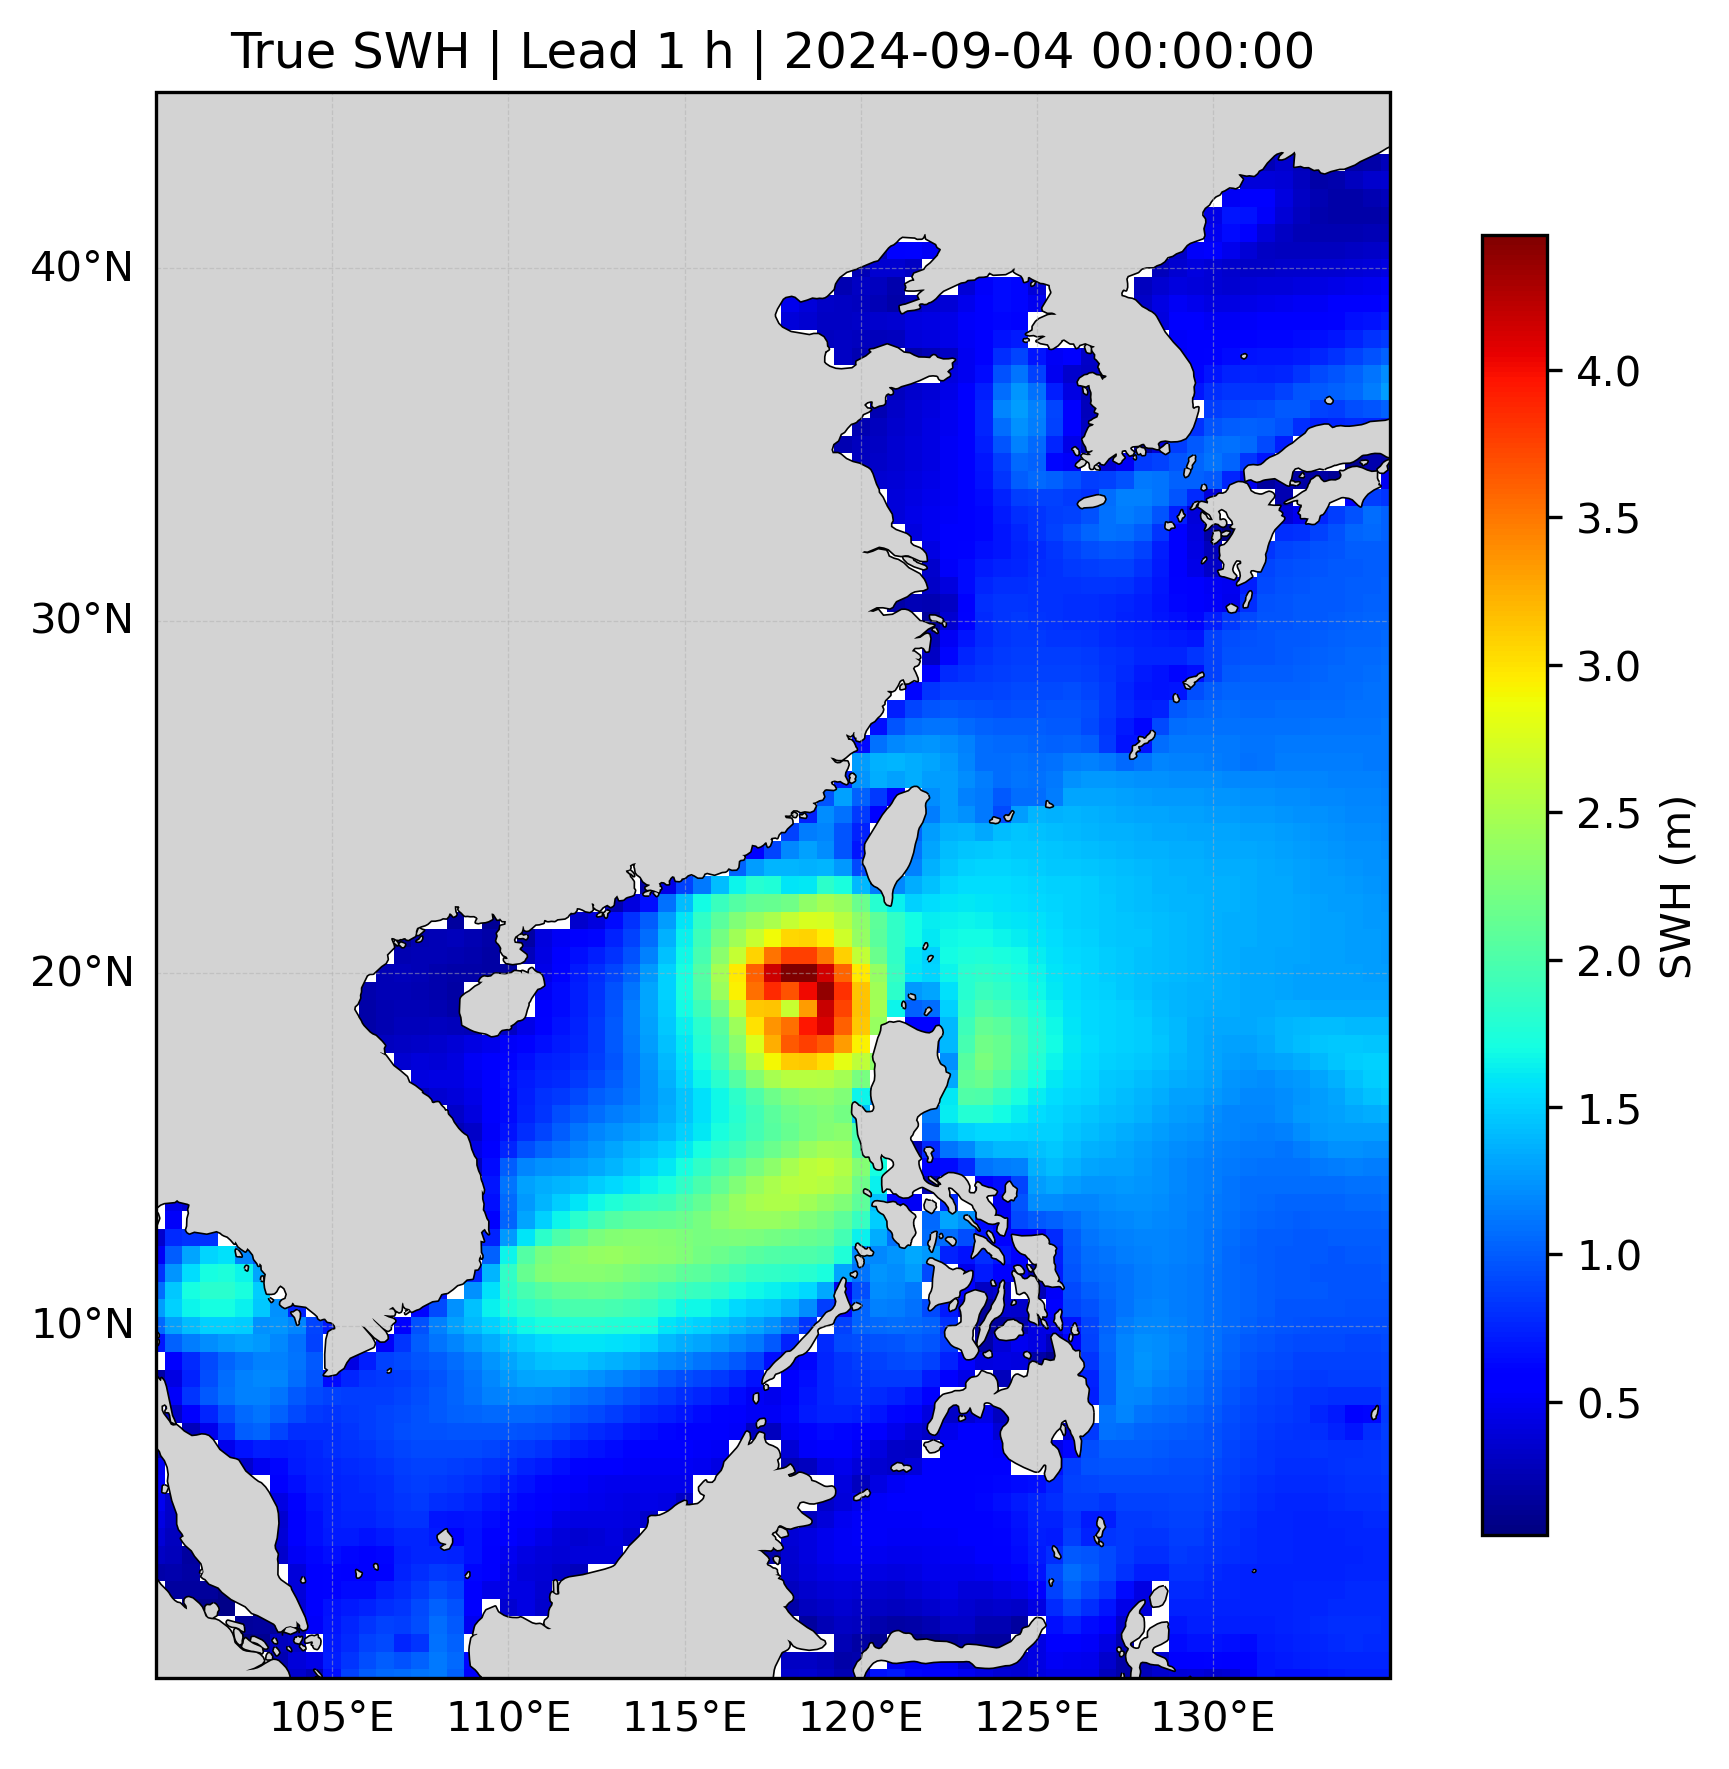

Saved: true_swh_validation_same_slice.png


In [4]:
# ============================================================
# Visualize one validation prediction using Cartopy
# Model: U-Net
# Same validation slice as previous tests
# ============================================================

# Only visualization-specific libraries are imported here.
# Core libraries are already imported in the training pipeline cell.
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================
# 1. Basic settings
# =========================
DATA_FILES = [
    "combined_wind_wave_2023.nc",
    "combined_wind_wave_2024.nc"
]

VAL_START = "2024-09-01"
VAL_END   = "2024-10-31"

MODEL_PATH = "wave_unet_2023_2024_demo/best_unet_swh.pth"

SAMPLE_ID = 0        # keep same validation sample
LEAD_ID = 0          # keep same forecast step

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# 2. U-Net model
# =========================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNetForecaster(nn.Module):
    def __init__(self, input_dim, seq_len, base_channels, pred_len):
        super().__init__()

        in_channels = input_dim * seq_len

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, pred_len, kernel_size=1)

    def match_size(self, x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)
        return x

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.reshape(B, T * C, H, W)  # (B, T*C, H, W)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.match_size(self.up4(b), e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.match_size(self.up3(d4), e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.match_size(self.up2(d3), e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.match_size(self.up1(d2), e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # (B, pred_len, H, W)


# =========================
# 3. Load checkpoint
# =========================
# The saved checkpoint stores the model weights and the normalization statistics
# required to convert predictions back to physical wave height values.
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)

config = ckpt["config"]
x_mean = ckpt["x_mean"]
x_std = ckpt["x_std"]
y_mean = ckpt["y_mean"]
y_std = ckpt["y_std"]
sea_mask = ckpt["sea_mask"]

model = UNetForecaster(
    input_dim=3,
    seq_len=config["seq_len"],
    base_channels=config["hidden_dim"],
    pred_len=config["pred_len"]
).to(DEVICE)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded model:", MODEL_PATH)


# =========================
# 4. Load validation data
# =========================
def get_time_dim(ds):
    for name in ["valid_time", "time"]:
        if name in ds.dims:
            return name
    raise ValueError("No time dimension found.")


datasets = [xr.open_dataset(f) for f in DATA_FILES]
time_dim = get_time_dim(datasets[0])

ds = xr.concat(
    datasets,
    dim=time_dim,
    coords="minimal",
    compat="override",
    combine_attrs="override"
).sortby(time_dim)

val_ds = ds.sel({time_dim: slice(VAL_START, VAL_END)})

u10 = val_ds["u10"].transpose(time_dim, ...).values.astype(np.float32)
v10 = val_ds["v10"].transpose(time_dim, ...).values.astype(np.float32)
swh = val_ds["swh"].transpose(time_dim, ...).values.astype(np.float32)

X_raw = np.stack([u10, v10, swh], axis=1)  # (T, C, H, W)
y_raw = swh                                # (T, H, W)

lon = val_ds["longitude"].values
lat = val_ds["latitude"].values
times = val_ds[time_dim].values

for d in datasets:
    d.close()


# =========================
# 5. Build same validation sample
# =========================
seq_len = config["seq_len"]
pred_len = config["pred_len"]
stride = config["stride"]

start = SAMPLE_ID * stride
end_x = start + seq_len
end_y = end_x + pred_len

x_seq = X_raw[start:end_x]
y_seq = y_raw[end_x:end_y]

x_norm = (x_seq - x_mean[None, :, None, None]) / (x_std[None, :, None, None] + 1e-6)
x_norm = np.nan_to_num(x_norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

x_tensor = torch.from_numpy(x_norm).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_norm = model(x_tensor).cpu().numpy()[0]

pred_swh = pred_norm * (y_std + 1e-6) + y_mean
true_swh = y_seq

pred_map = np.where(sea_mask > 0, pred_swh[LEAD_ID], np.nan)
true_map = np.where(sea_mask > 0, true_swh[LEAD_ID], np.nan)

target_time = times[end_x + LEAD_ID]
print("Prediction target time:", target_time)


# =========================
# 6. Plot function
# =========================
# The same color scale is used for prediction and truth to support visual comparison.
def plot_swh_map(field, title, save_path):
    fig = plt.figure(figsize=(8, 6), dpi=300)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent(
        [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())],
        crs=ccrs.PlateCarree()
    )

    im = ax.pcolormesh(
        lon,
        lat,
        field,
        cmap="jet",
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        linestyle="--",
        alpha=0.5
    )
    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.04)
    cbar.set_label("SWH (m)")

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=900, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


# =========================
# 7. Save prediction and truth maps
# =========================
plot_swh_map(
    pred_map,
    title=f"U-Net Predicted SWH | Lead {LEAD_ID + 1} h | 2024-09-04 00:00:00",
    save_path="unet_predicted_swh_validation.png"
)

plot_swh_map(
    true_map,
    title=f"True SWH | Lead {LEAD_ID + 1} h | 2024-09-04 00:00:00",
    save_path="true_swh_validation_same_slice.png"
)